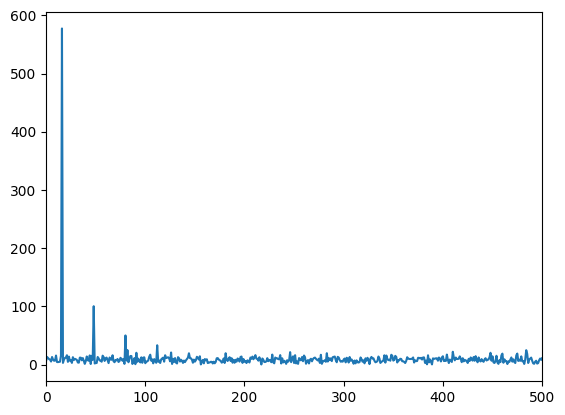

In [ ]:
#dft
import numpy as np
import matplotlib.pyplot as plt

def dft(y):
  N=len(y)
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k] +=y[n]*np.exp(-2j*np.pi*k*n/N)
  return c
y=np.loadtxt("pitch.txt",float)
c=dft(y)
plt.plot(abs(c))
plt.xlim(0,500)
plt.show()



1000


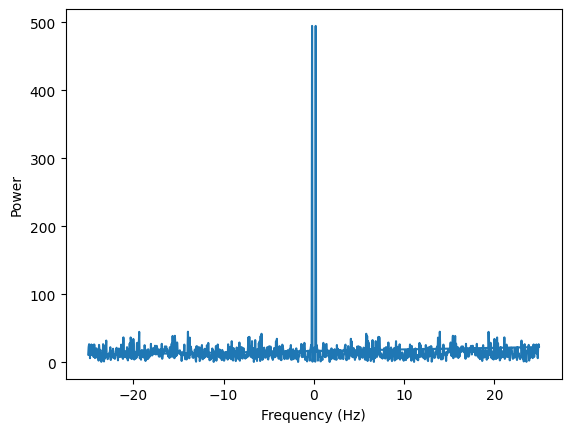

(array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 1

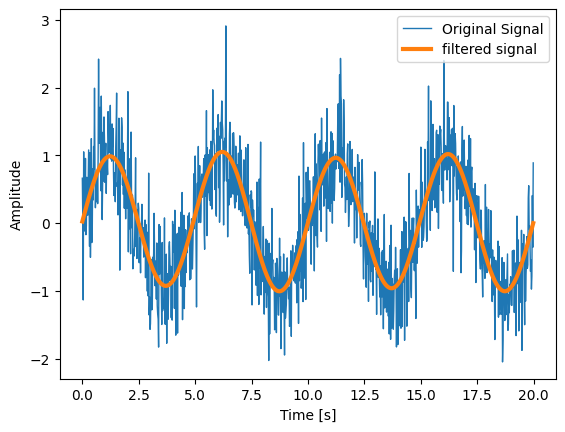

In [ ]:
import scipy.fftpack
import numpy as np
import matplotlib.pyplot as plt


time_step=0.02
period=5.0

time_vec=np.arange(0,20,time_step)
sig=(np.sin(2*np.pi/period*time_vec)+0.5*np.random.randn(time_vec.size))
sig_fft=scipy.fftpack.fft(sig)
power=np.abs(sig_fft)   #amplitude(진폭)
print(sig.size) #sig의 크기
sample_freq=scipy.fftpack.fftfreq(sig.size,d=time_step)
plt.plot(sample_freq,power)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.show()

pos_mask=np.where(sample_freq>0)
freqs=sample_freq[pos_mask]
peak_freq=freqs[power[pos_mask].argmax()]
print(peak_freq)

high_freq_fft=sig_fft.copy()
high_freq_fft[np.abs(sample_freq)>peak_freq]=0

filtered_sig=scipy.fftpack.ifft(high_freq_fft)
plt.plot(time_vec,sig,lw=1,label='Original Signal')
plt.plot(time_vec,filtered_sig.real,lw=3,label='filtered signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.legend()
plt.show()



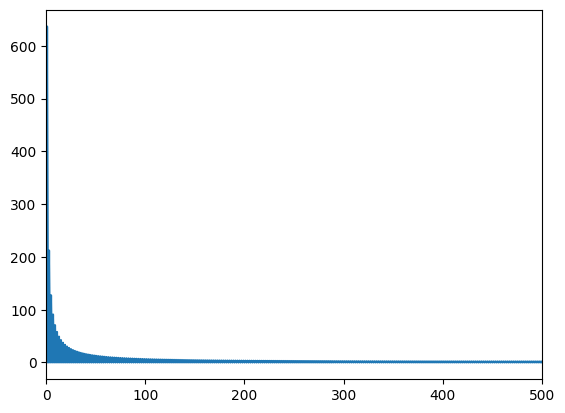

In [ ]:
#연습 7.1
import numpy as np
import matplotlib.pyplot as plt

def dft(y):
  N=len(y)
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k]+=y[n]*np.exp(-2j*np.pi*k*n/N)
  return c
y=np.ones(1000)
y[500:]=-1.0
c=dft(y)
plt.plot(abs(c))
plt.xlim(0,500)
plt.show()


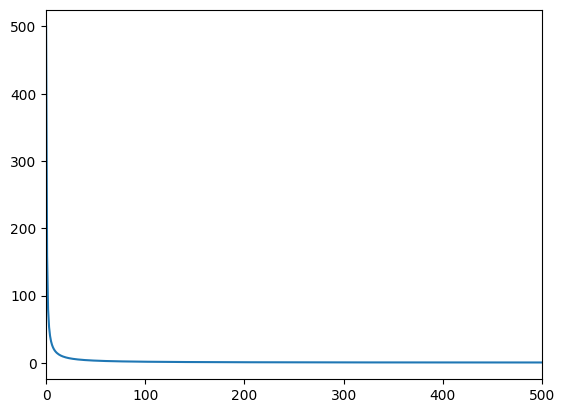

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def dft(y):
  N=len(y)
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k]+=y[n]*np.exp(-2j*np.pi*k*n/N)
  return c

y=np.linspace(0,1,1000)
c=dft(y)
plt.plot(abs(c))
plt.xlim(0,500)
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def dft(y):
  N=len(y)
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k]+=y[n]*np.exp(-2j*np.pi*k*n/N)
  return c



[0.000e+00 1.000e+00 2.000e+00 ... 3.140e+03 3.141e+03 3.142e+03]
[58.  62.6 70.  ... 25.2 23.5 21.6]


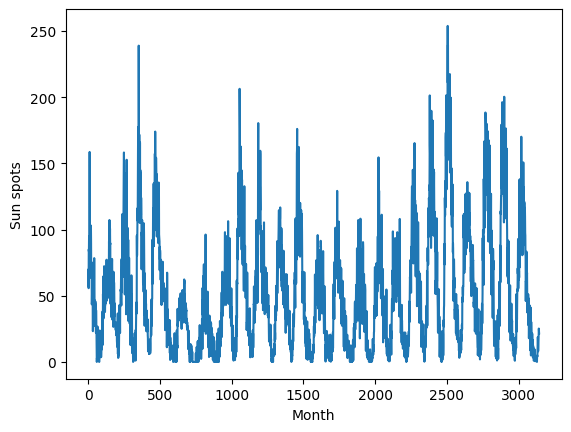

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("sunspots.txt",float)
m=y[:,0]
s=y[:,1]
print(m)
print(s)
plt.plot(m,s)
plt.xlabel('Month')
plt.ylabel('Sun spots')
plt.show()


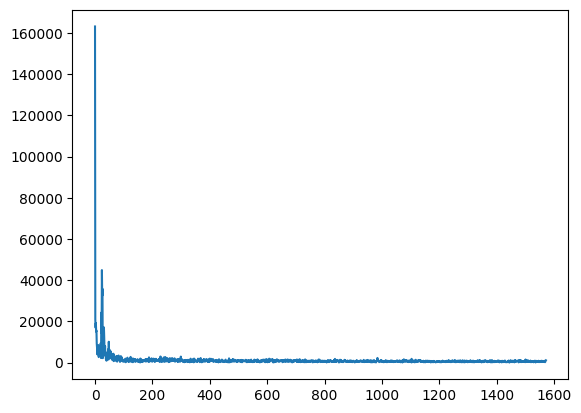

In [ ]:
#exercise 7.2(b)
import numpy as np
import matplotlib.pyplot as plt

def dft(y):
  N=len(y[:,1])
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k]+=y[:,1][n]*np.exp(-2j*np.pi*k*n/N)
  return c

y=np.loadtxt("sunspots.txt",float)
b=dft(y)
plt.plot(abs(b))
plt.show()




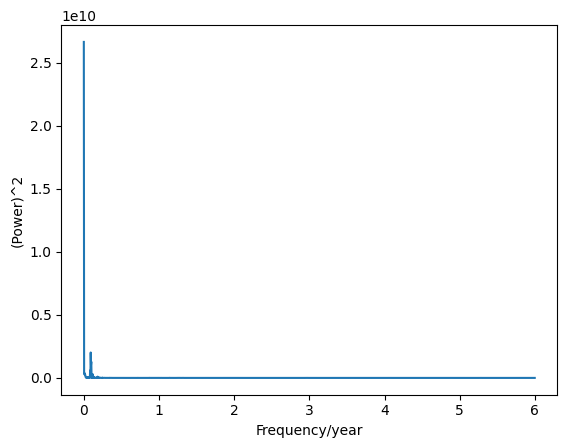

0.09163219853643018


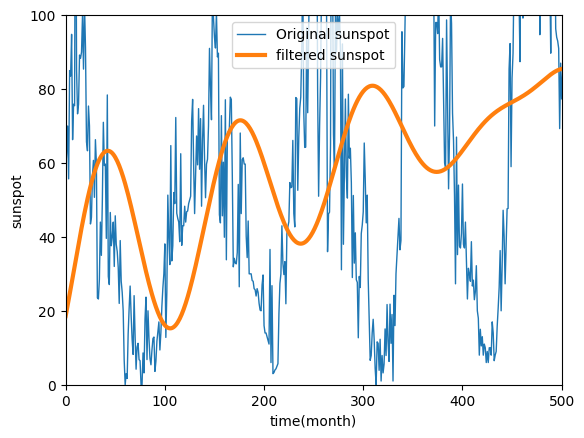

In [ ]:
from scipy.fft import rfft,rfftfreq,irfft
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("sunspots.txt",float)
y_rfft=rfft(y[:,1])
power=(np.abs(y_rfft))**2
sample_freq=rfftfreq(y[:,1].size,1/12)
plt.plot(sample_freq,power)
plt.xlabel("Frequency/year")
plt.ylabel("(Power)^2")
plt.show()

pos_mask=np.where(sample_freq>0)
freq=sample_freq[pos_mask]
peak_freq=freq[power[pos_mask].argmax()]
print(peak_freq)

high_freq_fft=y_rfft.copy()
high_freq_fft[np.abs(sample_freq)>peak_freq]=0

filtered_sig=scipy.fft.irfft(high_freq_fft, n=y[:,1].size)

plt.plot(y[:,0],y[:,1],lw=1,label='Original sunspot')
plt.plot(y[:,0],filtered_sig.real,lw=3,label='filtered sunspot')
plt.xlabel('time(month)')
plt.ylabel('sunspot')
plt.xlim(0,500)
plt.ylim(0,100)
plt.legend()
plt.show()

/tmp/ipykernel_8738/435483828.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


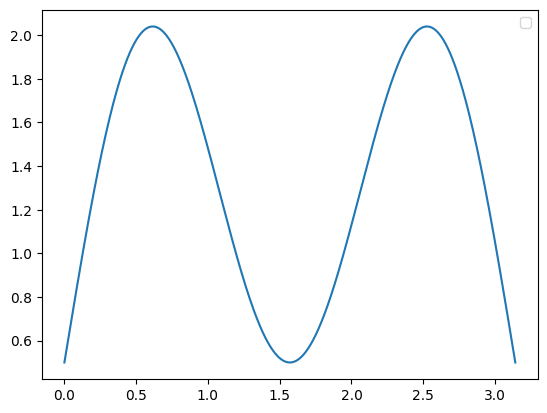

In [ ]:
#이산 코사인,사인 변환(scipy.dct,scipy.dst)
import numpy as np
from scipy.fft import dct,idct,dst,idst
import matplotlib.pyplot as plt

x=np.linspace(0,np.pi,1000)
y=np.sin(x)+0.5+np.sin(3*x)

y_dct=dct(y,type=2)
y_dct_recovered=idct(y_dct,type=2)

y_dst=dst(y,type=2)
y_dst_recovered=idst(y_dst,type=2)

plt.plot(x,y)
plt.legend()
plt.show()




In [ ]:
#fast fourier transforms
import scipy.fft
import numpy as np
import matplotlib.pyplot as plt

def func(t):
  return 2*np.sin(20*np.pi*t)+np.cos(50*np.pi*t)

N=128
t=np.arange(N)/float(N)
h=func(t)

H=scipy.fft.fft(h)
f=scipy.fft.fftfreq(N,1/N)

Hs=scipy.fft.fftshift(H)
fs=scipy.fft.fftshift(f)

fig=plt.figure(1,figsize=(12,8))
plt.subplot(221)
t1=np.linspace(0,1,1000)
plt.plot(t1,func(t1))
plt.plot(t,h,'.')
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.text(0,2.5,'(a)')
plt.subplot()


In [ ]:
#exercise7.3 fourier transforms of musical instruments
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("piano.txt",float)

def dft(y):
  N=len(y)
  c=np.zeros(N//2+1,complex)
  for k in range(N//2+1):
    for n in range(N):
      c[k]+=y[n]*np.exp(-2j*np.pi*k*n/N)
  return c

c=dft(y)
plt.plot(abs(c))
plt.show

#자체 함수를 쓸땐 복소수 곱셈을 100억번을 해야된다.

FileNotFoundError: piano.txt not found.

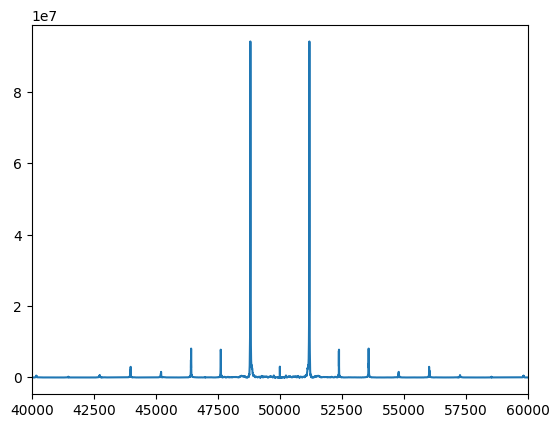

In [ ]:
import scipy.fft
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("piano.txt",float)
c=scipy.fft.fft(y)
d=scipy.fft.fftshift(c)
plt.plot(abs(d))
plt.xlim(40000,60000)
plt.show()


[-1922.           -0.j         -1194.86472202-1147.21323225j
 -2595.49743258-1345.55104643j ...  -745.96875361 -589.39183789j
 -2595.49743258+1345.55104643j -1194.86472202+1147.21323225j]


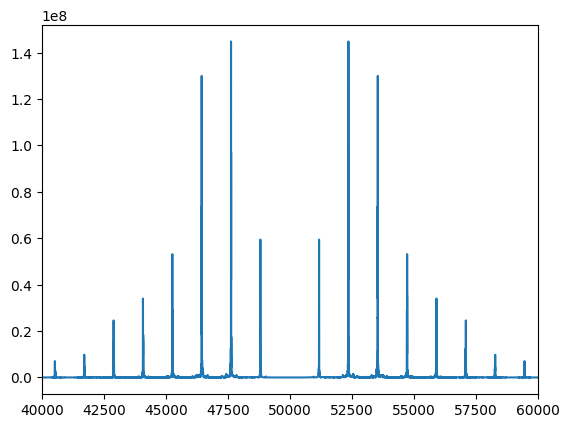

In [ ]:
import scipy.fft
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("trumpet.txt",float)
c=scipy.fft.fft(y)
d=scipy.fft.fftshift(c)
print(d)
plt.plot(abs(d))
plt.xlim(40000,60000)
plt.show()



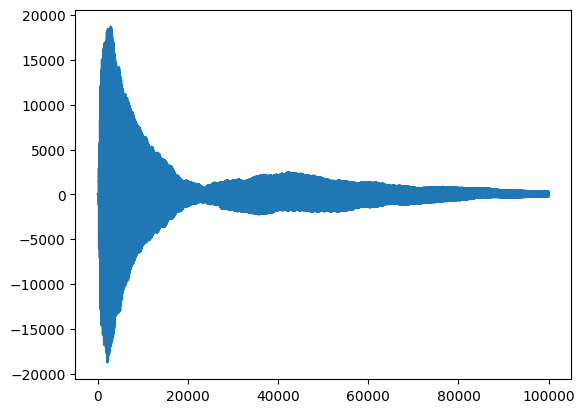

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("piano.txt",float)
plt.plot(y)
plt.show()

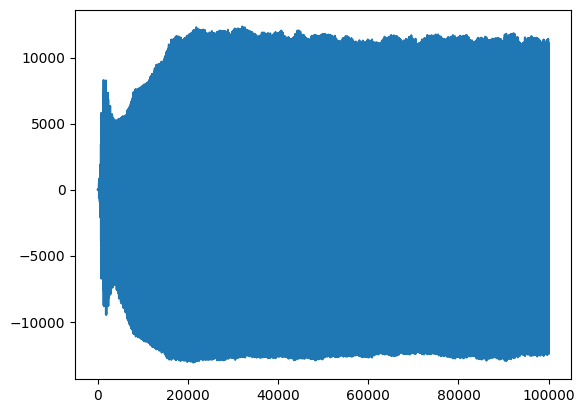

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("trumpet.txt",float)
plt.plot(y)
plt.show()

In [ ]:
#7.3 문제 결론 트럼프에 주파수가 피아노보다 더 많이 섞여있다.

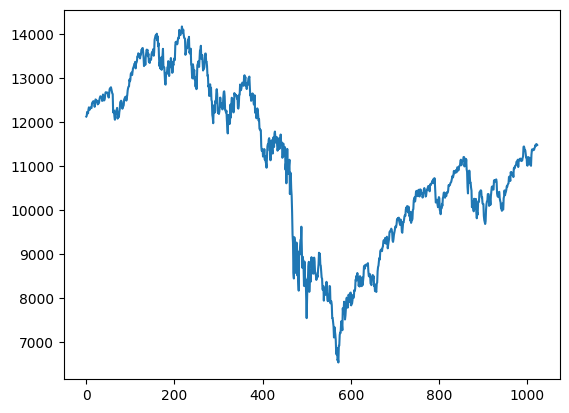

In [ ]:
#7.4 문제 dow.txt
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("dow.txt",float)
plt.plot(y)
plt.show()

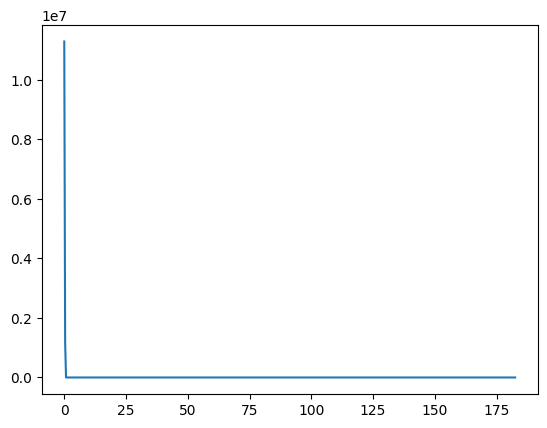

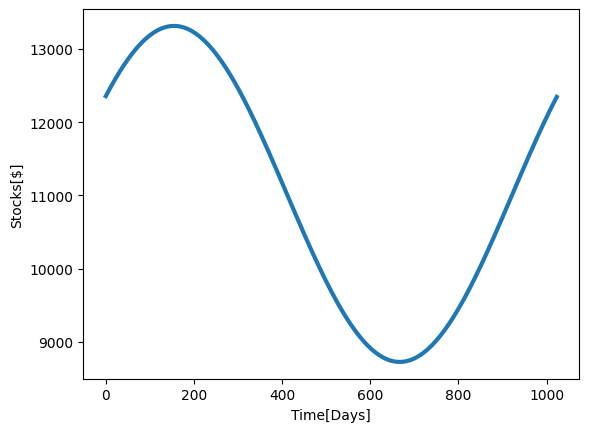

In [ ]:
#7.4 문제 (b),(c)
import scipy.fft
import numpy as np
import matplotlib.pyplot as plt

y=np.loadtxt("dow.txt",float)
d=scipy.fft.rfft(y)
dow_freq=scipy.fft.rfftfreq(len(y),1/365)

tenper=np.where(dow_freq<0.6)
nineper=np.where(dow_freq>0.6)
d[nineper]=0
plt.plot(dow_freq,np.abs(d))
plt.show()

sig=scipy.fft.irfft(d,n=len(y))
plt.plot(sig,lw=3)
plt.xlabel('Time[Days]')
plt.ylabel('Stocks[$]')
plt.show()

#어려웠던점:푸리에에 대한 데이터 추출
